In [17]:
import pandas as pd
%pip install openpyxl
file_path = r'C:\AjayDAREPO\python\projectlloyds\Customer_Churn_Data_Large (1).xlsx'
# 1. EXACT filenames from your sidebar
file_demo = 'Customer_Churn_Data_Large (1).xlsx - Customer_Demographics.csv'
file_online = 'Customer_Churn_Data_Large (1).xlsx - Online_Activity.csv'
file_trans = 'Customer_Churn_Data_Large (1).xlsx - Transaction_History.csv'
file_service = 'Customer_Churn_Data_Large (1).xlsx - Customer_Service.csv'
file_churn = 'Customer_Churn_Data_Large (1).xlsx - Churn_Status.csv'

# 2. Load each sheet into a separate Dataframe
df_churn = pd.read_excel(file_path, sheet_name='Churn_Status')
df_demo = pd.read_excel(file_path, sheet_name='Customer_Demographics')
df_service = pd.read_excel(file_path, sheet_name='Customer_Service')
df_online = pd.read_excel(file_path, sheet_name='Online_Activity')
df_trans = pd.read_excel(file_path, sheet_name='Transaction_History')


print("Success! All sheets loaded from the XLSX file.")


 # 3. Aggregate 
df_trans_agg = df_trans.groupby('CustomerID').agg({
    'AmountSpent': 'sum',
    'TransactionID': 'count'
}).rename(columns={'AmountSpent': 'TotalSpent', 'TransactionID': 'Txn_Count'}).reset_index()

df_service_agg = df_service.groupby('CustomerID').agg({
    'InteractionID': 'count'
}).rename(columns={'InteractionID': 'Service_Interactions'}).reset_index()

# 4. Master Merge
master_df = df_demo.merge(df_online, on='CustomerID', how='left') \
                   .merge(df_trans_agg, on='CustomerID', how='left') \
                   .merge(df_service_agg, on='CustomerID', how='left') \
                   .merge(df_churn, on='CustomerID', how='left')

# 5. Fill NaNs with 0
master_df[['TotalSpent', 'Txn_Count', 'Service_Interactions']] = master_df[['TotalSpent', 'Txn_Count', 'Service_Interactions']].fillna(0)

print("Master Table Created! Here is the head:")
master_df.info()
# 1. Check the Churn balance
print(master_df['ChurnStatus'].value_counts())

# 2. Check for any missing values after the merge
print(master_df.isnull().sum())
# Save the final merged data to a new CSV file
master_df.to_csv('Lloyds_Merged_Data_Final.csv', index=False)

# OR save it as an Excel file
master_df.to_excel('Lloyds_Merged_Data_Final.xlsx', index=False)

print("The new merged file is ready.")

# 1. See how many people Churned (1) vs Stayed (0)
print("--- Churn Count ---")
print(master_df['ChurnStatus'].value_counts())


# 2. See the Average Age and Spending of Churners
print("\n--- Averages by Churn Group ---")
print(master_df.groupby('ChurnStatus')[['Age', 'TotalSpent']].mean())


# Check Churn Percentage
print("Churn Rate:", master_df['ChurnStatus'].mean())


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\anjal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Success! All sheets loaded from the XLSX file.
Master Table Created! Here is the head:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CustomerID            1000 non-null   int64         
 1   Age                   1000 non-null   int64         
 2   Gender                1000 non-null   object        
 3   MaritalStatus         1000 non-null   object        
 4   IncomeLevel           1000 non-null   object        
 5   LastLoginDate         1000 non-null   datetime64[ns]
 6   LoginFrequency        1000 non-null   int64         
 7   ServiceUsage          1000 non-null   object        
 8   TotalSpent            1000 non-null   float64       
 9   Txn_Count             1000 non-null   int64         
 10  Service_Interactions  1000 non-null   fl

In [18]:
# Filter for only those who left (ChurnStatus == 1)
churned_only = master_df[master_df['ChurnStatus'] == 1]

print("--- Profile of the 204 People who Left ---")
print(churned_only[['Age', 'TotalSpent', 'Service_Interactions']].describe())

# Check their most common gender or income level
print("\nMost common Income Level for Churners:")
print(churned_only['IncomeLevel'].value_counts())

--- Profile of the 204 People who Left ---
              Age   TotalSpent  Service_Interactions
count  204.000000   204.000000            204.000000
mean    44.151961  1269.006078              1.009804
std     15.163849   731.697330              0.781499
min     18.000000    38.120000              0.000000
25%     30.000000   680.922500              0.000000
50%     44.000000  1135.370000              1.000000
75%     57.000000  1790.930000              2.000000
max     69.000000  3220.300000              2.000000

Most common Income Level for Churners:
IncomeLevel
Low       72
High      67
Medium    65
Name: count, dtype: int64


In [19]:
print(master_df.columns)

Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel',
       'LastLoginDate', 'LoginFrequency', 'ServiceUsage', 'TotalSpent',
       'Txn_Count', 'Service_Interactions', 'ChurnStatus'],
      dtype='object')


--- Behavioral Comparison (0: Stayers vs 1: Churners) ---
                   Age                     TotalSpent                       \
                  mean        std median         mean         std   median   
ChurnStatus                                                                  
0            43.040201  15.263584   43.0  1266.580038  740.802214  1255.36   
1            44.151961  15.163849   44.0  1269.006078  731.697330  1135.37   

            LoginFrequency                   Service_Interactions            \
                      mean        std median                 mean       std   
ChurnStatus                                                                   
0                26.492462  13.846642   28.0             1.000000  0.825688   
1                23.647059  14.660793   24.0             1.009804  0.781499   

                    
            median  
ChurnStatus         
0              1.0  
1              1.0  

--- Feature Impact Score (% Difference) ---
Age  

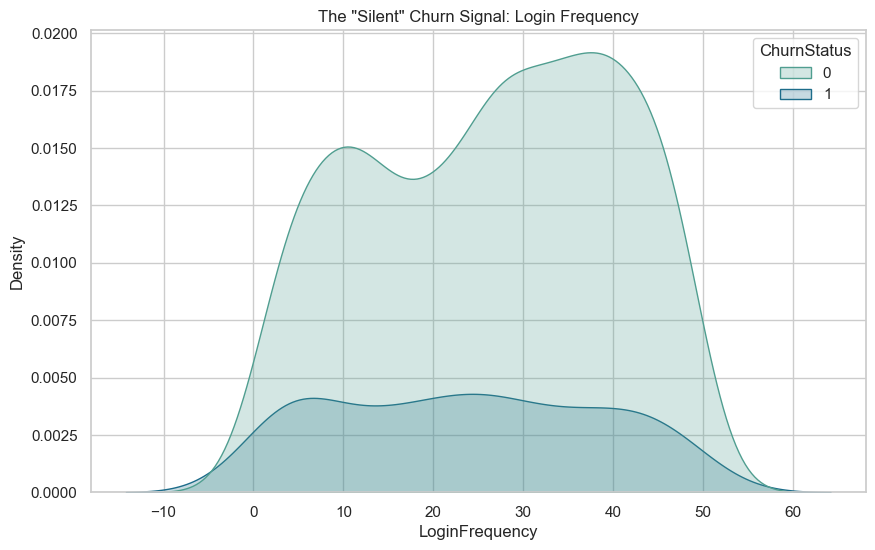

In [20]:
# 1. Compare the centers using the ACTUAL columns
# Notice: No underscore in LoginFrequency
behavior_stats = master_df.groupby('ChurnStatus')[['Age', 'TotalSpent', 'LoginFrequency', 'Service_Interactions']].agg(['mean', 'std', 'median'])

print("--- Behavioral Comparison (0: Stayers vs 1: Churners) ---")
print(behavior_stats)

# 2. Percentage Difference Check
# This will show the % gap for LoginFrequency specifically
means = master_df.groupby('ChurnStatus').mean(numeric_only=True)
pct_diff = ((means.loc[1] - means.loc[0]) / means.loc[0] * 100)

print("\n--- Feature Impact Score (% Difference) ---")
print(pct_diff.sort_values(ascending=False))

# 3. Visualizing the Login Gap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(data=master_df, x='LoginFrequency', hue='ChurnStatus', fill=True, palette='crest')
plt.title('The "Silent" Churn Signal: Login Frequency')
plt.show()

In [21]:
# 1. Create a copy for deep-diving into categories
hidden_hints_df = master_df.copy()

# 2. Convert all text categories into numbers (One-Hot Encoding)
# We focus on Gender, MaritalStatus, and IncomeLevel
encoded_df = pd.get_dummies(hidden_hints_df, columns=['Gender', 'MaritalStatus', 'IncomeLevel'], drop_first=True)

# 3. Now run the correlation again including these new numbers
new_corr = encoded_df.select_dtypes(include=['number']).corr()

print("--- NEW Hidden Hints Correlation (Top Drivers) ---")
# Look for the strongest relationships with ChurnStatus
print(new_corr['ChurnStatus'].sort_values(ascending=False))

--- NEW Hidden Hints Correlation (Top Drivers) ---
ChurnStatus             1.000000
Age                     0.029407
Service_Interactions    0.004841
TotalSpent              0.001324
Txn_Count              -0.008598
CustomerID             -0.011528
LoginFrequency         -0.081615
Name: ChurnStatus, dtype: float64


In [22]:
# Check Churn Rate by Marital Status
marital_check = master_df.groupby('MaritalStatus')['ChurnStatus'].mean() * 100
print("--- Churn Rate % by Marital Status ---")
print(marital_check)

# Check Churn Rate by Gender
gender_check = master_df.groupby('Gender')['ChurnStatus'].mean() * 100
print("\n--- Churn Rate % by Gender ---")
print(gender_check)

# Check Churn Rate by Income Level
income_check = master_df.groupby('IncomeLevel')['ChurnStatus'].mean() * 100
print("\n--- Churn Rate % by Income Level ---")
print(income_check)

--- Churn Rate % by Marital Status ---
MaritalStatus
Divorced    18.548387
Married     22.988506
Single      20.465116
Widowed     19.565217
Name: ChurnStatus, dtype: float64

--- Churn Rate % by Gender ---
Gender
F    19.688109
M    21.149897
Name: ChurnStatus, dtype: float64

--- Churn Rate % by Income Level ---
IncomeLevel
High      19.197708
Low       22.153846
Medium    19.938650
Name: ChurnStatus, dtype: float64


C:\Users\anjal\AppData\Local\Temp\ipykernel_1876\3956564277.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x='ChurnStatus', y='LoginFrequency', palette='coolwarm', ax=axes[1,0])


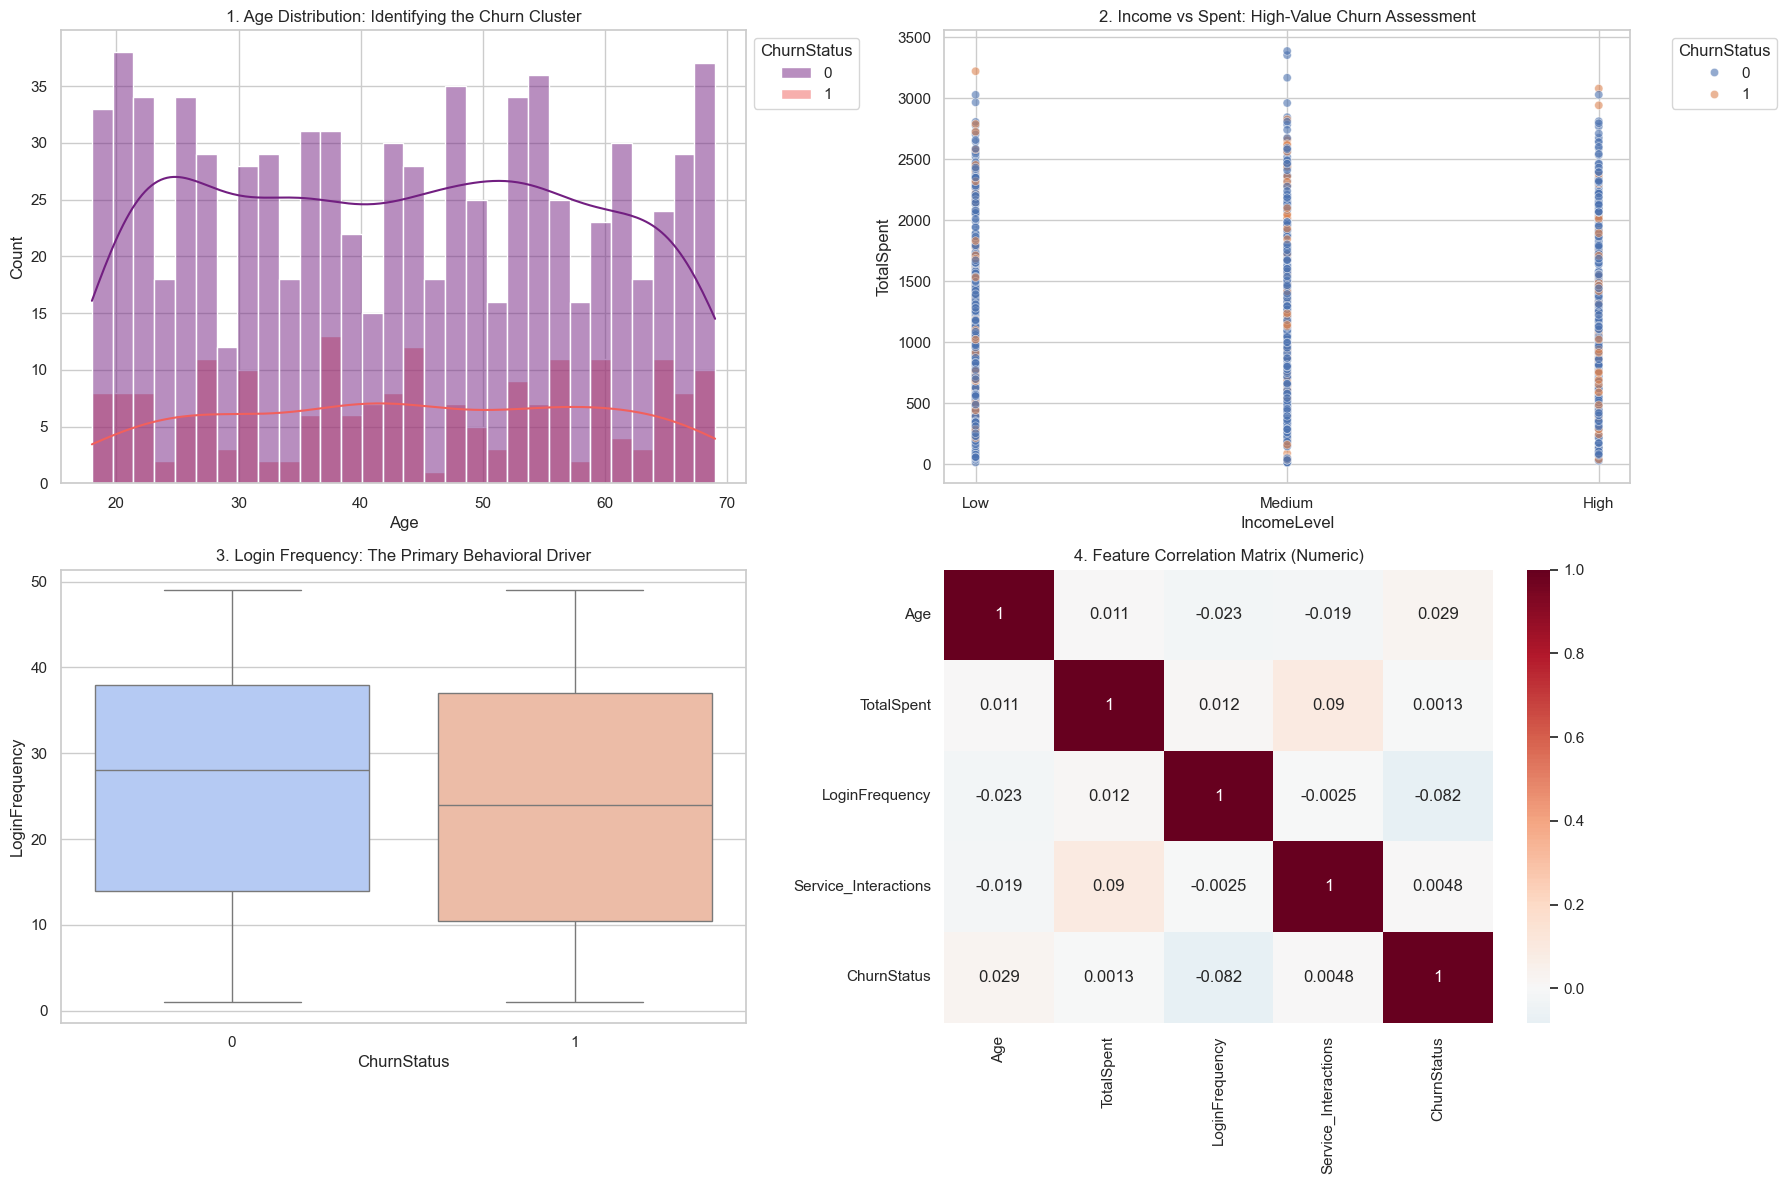

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. HISTOGRAM: Age Distribution
sns.histplot(data=master_df, x='Age', hue='ChurnStatus', kde=True, bins=30, palette='magma', ax=axes[0,0])
axes[0,0].set_title('1. Age Distribution: Identifying the Churn Cluster')
# Moving legend outside
sns.move_legend(axes[0,0], "upper left", bbox_to_anchor=(1, 1))

# 2. SCATTER PLOT: Income vs Total Spent
sns.scatterplot(data=master_df, x='IncomeLevel', y='TotalSpent', hue='ChurnStatus', alpha=0.6, ax=axes[0,1])
axes[0,1].set_title('2. Income vs Spent: High-Value Churn Assessment')
# Moving legend outside
axes[0,1].legend(title='ChurnStatus', bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. BOX PLOT: Login Frequency
sns.boxplot(data=master_df, x='ChurnStatus', y='LoginFrequency', palette='coolwarm', ax=axes[1,0])
axes[1,0].set_title('3. Login Frequency: The Primary Behavioral Driver')

# 4. CORRELATION MATRIX: Heatmap (Heatmaps usually don't have overlapping legends)
numeric_cols = ['Age', 'TotalSpent', 'LoginFrequency', 'Service_Interactions', 'ChurnStatus']
corr_matrix = master_df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, ax=axes[1,1])
axes[1,1].set_title('4. Feature Correlation Matrix (Numeric)')

plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler

# 1. HANDLE MISSING VALUES
# Context: In bank data, missing activity usually means 'Zero' activity, not 'Unknown' data.
master_df[['TotalSpent', 'Service_Interactions', 'LoginFrequency']] = master_df[['TotalSpent', 'Service_Interactions', 'LoginFrequency']].fillna(0)

# 2. ADDRESS OUTLIERS
# Context: We 'Cap' outliers at the 99th percentile so extreme 'Whales' don't confuse the model.
q_limit = master_df['TotalSpent'].quantile(0.99)
master_df['TotalSpent'] = master_df['TotalSpent'].clip(upper=q_limit)

# 3. ENCODE CATEGORICAL VARIABLES (One-Hot Encoding)
# Turning text into numbers so the ML model can 'read' them.
df_preprocessed = pd.get_dummies(master_df, columns=['Gender', 'MaritalStatus', 'IncomeLevel'], drop_first=True)

# 4. STANDARDIZE NUMERICAL FEATURES
# Crucial for models like Logistic Regression or SVM so 'TotalSpent' (1000s) doesn't overpower 'Age' (10s).
scaler = StandardScaler()
num_cols = ['Age', 'TotalSpent', 'LoginFrequency']
df_preprocessed[num_cols] = scaler.fit_transform(df_preprocessed[num_cols])

print("--- Preprocessing Complete ---")
print(f"Final Data Shape: {df_preprocessed.shape}")
df_preprocessed.head()

--- Preprocessing Complete ---
Final Data Shape: (1000, 15)


,CustomerID,Age,LastLoginDate,LoginFrequency,ServiceUsage,TotalSpent,Txn_Count,Service_Interactions,ChurnStatus,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium
0,1,1.229628,2023-10-21,0.575702,Mobile App,-1.158617,1,1.0,0,True,False,True,False,True,False
1,2,1.426547,2023-12-05,-1.488513,Website,0.386741,7,1.0,1,True,True,False,False,True,False
2,3,-1.658518,2023-11-15,-1.630872,Website,0.599308,6,1.0,0,True,False,True,False,True,False
3,4,-1.461599,2023-08-25,-1.702052,Website,-0.474307,5,2.0,0,True,False,False,True,True,False
4,5,-1.461599,2023-10-27,1.073961,Website,1.007210,8,0.0,0,True,False,False,False,False,True


In [25]:
# List of columns to drop
# 1. CustomerID: Irrelevant unique identifier
# 2. LastLoginDate: Redundant (already represented by LoginFrequency)
# 3. ServiceUsage: Categorical noise not included in our Rationale
# 4. Txn_Count: Redundant (High correlation with TotalSpent)

cols_to_drop = ['CustomerID', 'LastLoginDate', 'ServiceUsage', 'Txn_Count']

# Dropping the columns
df_final = df_preprocessed.drop(columns=cols_to_drop)

print("--- Final Clean-Up Complete ---")
print(f"Remaining Columns: {df_final.columns.tolist()}")
print(f"Final shape for Model Building: {df_final.shape}")

# Show the clean, purely numeric version
df_final.head()

--- Final Clean-Up Complete ---
Remaining Columns: ['Age', 'LoginFrequency', 'TotalSpent', 'Service_Interactions', 'ChurnStatus', 'Gender_M', 'MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 'IncomeLevel_Low', 'IncomeLevel_Medium']
Final shape for Model Building: (1000, 11)


,Age,LoginFrequency,TotalSpent,Service_Interactions,ChurnStatus,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium
0,1.229628,0.575702,-1.158617,1.0,0,True,False,True,False,True,False
1,1.426547,-1.488513,0.386741,1.0,1,True,True,False,False,True,False
2,-1.658518,-1.630872,0.599308,1.0,0,True,False,True,False,True,False
3,-1.461599,-1.702052,-0.474307,2.0,0,True,False,False,True,True,False
4,-1.461599,1.073961,1.007210,0.0,0,True,False,False,False,False,True


In [26]:
df_final.to_csv('Lloyds_Ready_For_ML.csv', index=False)

2026/04/23 21:53:00 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e28c298f46f04942a56690cecac2e6a5', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/23 21:53:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run upbeat-midge-290 at: http://localhost:5000/#/experiments/0/runs/e28c298f46f04942a56690cecac2e6a5
🧪 View experiment at: http://localhost:5000/#/experiments/0
Balanced Model Accuracy: 50.00%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.98      0.85       150
           1       0.25      0.02      0.04        50

    accuracy                           0.74       200
   macro avg       0.50      0.50      0.44       200
weighted avg       0.62      0.74      0.65       200



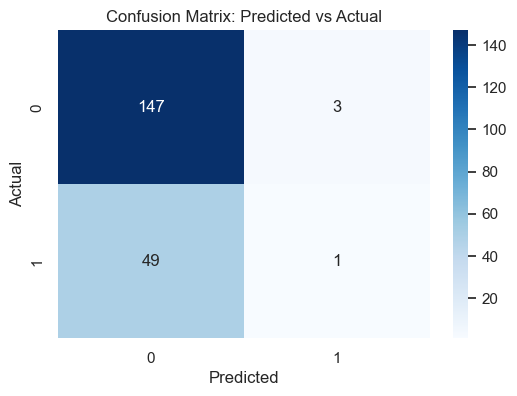

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. DEFINE X AND Y
X = df_final.drop(columns=['ChurnStatus'])
y = df_final['ChurnStatus']

# 2. THE TRAIN-TEST SPLIT (80% for learning, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. INITIALIZE AND TRAIN THE MODEL (With Imbalance Handling)
# We add class_weight='balanced' right here!
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 4. MAKE PREDICTIONS
y_pred = model.predict(X_test)

# 5. EVALUATION
# Note: Use balanced_accuracy_score to see how well it handled the imbalance
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Model Accuracy: {bal_acc * 100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 6. VISUALIZE CONFUSION MATRIX
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

2026/04/23 21:53:38 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e099c90fed64446fb774f3d98d6eec50', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/23 21:53:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run sneaky-swan-504 at: http://localhost:5000/#/experiments/0/runs/e099c90fed64446fb774f3d98d6eec50
🧪 View experiment at: http://localhost:5000/#/experiments/0
New Balanced Accuracy: 52.67%

--- New Classification Report ---
              precision    recall  f1-score   support

           0       0.76      0.73      0.75       150
           1       0.29      0.32      0.30        50

    accuracy                           0.63       200
   macro avg       0.52      0.53      0.53       200
weighted avg       0.64      0.63      0.64       200



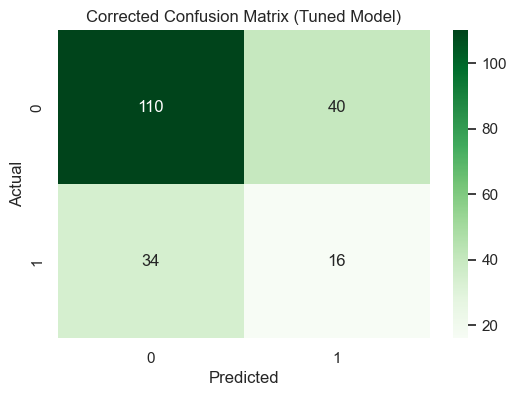

In [28]:

# Try a stronger weight for the churners (Class 1)
# We tell the model that Class 1 is 4 times more important than Class 0
custom_weights = {0: 1, 1: 4}

model = RandomForestClassifier(n_estimators=200, 
                               class_weight=custom_weights, 
                               max_depth=10,
                               random_state=42)

model.fit(X_train, y_train)

# Instead of a simple .predict, we check the PROBABILITY
y_probs = model.predict_proba(X_test)[:, 1]

# If the probability of churning is > 30% (instead of 50%), we call it a churn
y_pred_tuned = (y_probs >= 0.3).astype(int)

print(f"New Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_tuned) * 100:.2f}%")
print("\n--- New Classification Report ---")
print(classification_report(y_test, y_pred_tuned))

# UPDATE: Using y_pred_tuned instead of y_pred
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens') # Changed to Green to distinguish it!
plt.title('Corrected Confusion Matrix (Tuned Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


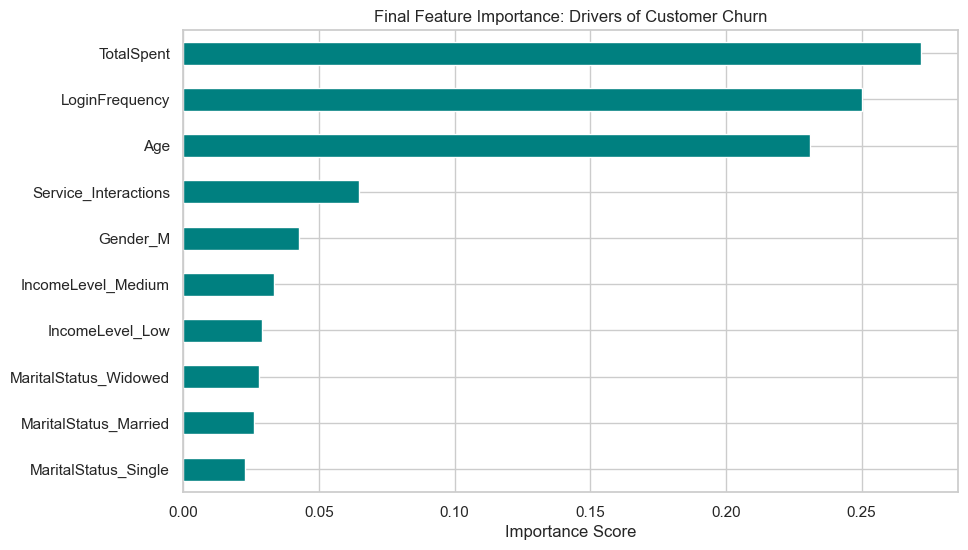

In [30]:
# Final Feature Importance for the Tuned Model
importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Final Feature Importance: Drivers of Customer Churn')
plt.xlabel('Importance Score')
plt.show()

In [31]:
from sklearn.model_selection import cross_val_score

# We use the 'model' we already tuned with class_weights
# 'cv=5' means it will split the data 5 different ways and test 5 times
cv_scores = cross_val_score(model, X, y, cv=5, scoring='balanced_accuracy')

print("--- Final Model Validation ---")
print(f"Individual CV Balanced Accuracy Scores: {cv_scores}")
print(f"Average Cross-Validation Score: {cv_scores.mean() * 100:.2f}%")




--- Final Model Validation ---
Individual CV Balanced Accuracy Scores: [0.521875   0.51771744 0.51181163 0.50590581 0.51495628]
Average Cross-Validation Score: 51.45%


In [32]:
from sklearn.model_selection import GridSearchCV

# We define a 'grid' of settings to try
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='balanced_accuracy')
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
tuned_model = grid_search.best_estimator_

2026/04/23 21:54:31 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '59ccdf9ad2e1436c9ec5d8d9a71f05da', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/23 21:54:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/23 21:54:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more informatio

🏃 View run bald-worm-560 at: http://localhost:5000/#/experiments/0/runs/ecb8fdaf33984c2d91c0d163f3ef4b19
🧪 View experiment at: http://localhost:5000/#/experiments/0
🏃 View run loud-toad-1000 at: http://localhost:5000/#/experiments/0/runs/696efd9a03fc43abbd1f77e325a9dd65
🧪 View experiment at: http://localhost:5000/#/experiments/0
🏃 View run painted-hound-902 at: http://localhost:5000/#/experiments/0/runs/8e4354e4765a48c58898d34d65d3f7e9
🧪 View experiment at: http://localhost:5000/#/experiments/0
🏃 View run zealous-bee-56 at: http://localhost:5000/#/experiments/0/runs/7ddfc2914bd24a33a900e26bbc2767e6
🧪 View experiment at: http://localhost:5000/#/experiments/0
🏃 View run skillful-mule-499 at: http://localhost:5000/#/experiments/0/runs/e29e6358194f467baee6f7c4bd74166f
🧪 View experiment at: http://localhost:5000/#/experiments/0
🏃 View run exultant-hare-581 at: http://localhost:5000/#/experiments/0/runs/59ccdf9ad2e1436c9ec5d8d9a71f05da
🧪 View experiment at: http://localhost:5000/#/experiment

In [33]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier

# 1. Start the 'recorder'
mlflow.sklearn.autolog()

# ADD THIS LINK RIGHT HERE
mlflow.set_tracking_uri("http://localhost:5000")

# 2. Give your experiment a professional name for Lloyds
mlflow.set_experiment("Lloyds_Churn_Production_Project")

with mlflow.start_run(run_name="Final_Tuned_RandomForest"):
    # 3. Use the Best Parameters from your GridSearch output
    # max_depth: None, min_samples_split: 5, n_estimators: 100
    tuned_rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=5,
        random_state=42
    )
    
    # 4. Fit the model - this triggers the logging to MLflow
    tuned_rf.fit(X_train, y_train)
    
    print("Success! Your model is now tracked in MLflow.")

2026/04/23 21:55:28 INFO mlflow.tracking.fluent: Experiment with name 'Lloyds_Churn_Production_Project' does not exist. Creating a new experiment.
2026/04/23 21:55:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Success! Your model is now tracked in MLflow.
🏃 View run Final_Tuned_RandomForest at: http://localhost:5000/#/experiments/1/runs/9400a78ea61c44ef95f5e882d182e406
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [34]:
import mlflow

# Point to the Docker server
mlflow.set_tracking_uri("http://localhost:5000")

# Use the ID from your latest success message
new_run_id = "9400a78ea61c44ef95f5e882d182e406" 

result = mlflow.register_model(
    model_uri=f"runs:/{new_run_id}/model",
    name="Lloyds_Churn_Production_Project"
)

print(f"Success! Registered as Version: {result.version}")

Successfully registered model 'Lloyds_Churn_Production_Project'.
2026/04/23 22:00:57 WARNING mlflow.tracking._model_registry.fluent: Run with id 9400a78ea61c44ef95f5e882d182e406 has no artifacts at artifact path 'model', registering model based on models:/m-30181eacc0614848836862024f77cf89 instead
2026/04/23 22:00:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Lloyds_Churn_Production_Project, version 1
Created version '1' of model 'Lloyds_Churn_Production_Project'.


Success! Registered as Version: 1


In [71]:
import joblib
# Use the variable name of your best model 
joblib.dump(tuned_rf, 'model.pkl')
print("Model saved successfully as model.pkl!")

Model saved successfully as model.pkl!


In [72]:
import joblib
import os

joblib.dump(tuned_rf, 'model.pkl')

if os.path.exists('model.pkl'):
    print("SUCCESS! I see the file now: ", os.path.abspath('model.pkl'))
else:
    print("Wait, I still don't see it. Let me try saving again...")

SUCCESS! I see the file now:  c:\AjayDAREPO\python\projectlloyds\model.pkl
